In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import poisson
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
hist_matches = pd.read_csv(r"C:\Users\Flavio\OneDrive\Progetti\World Cup\results.csv", sep=';')
hist_matches['date'] = pd.to_datetime(hist_matches['date'])
hist_matches = hist_matches.iloc[:, 0:6]    # .dropna() droppa solo le ultime righe dei quarti

hist_matches

,date,home_team,away_team,home_score,away_score,tournament
0,1872-11-30,Scotland,England,0.0,0.0,Friendly
1,1873-03-08,England,Scotland,4.0,2.0,Friendly
2,1874-03-07,Scotland,England,2.0,1.0,Friendly
3,1875-03-06,England,Scotland,2.0,2.0,Friendly
4,1876-03-04,Scotland,England,3.0,0.0,Friendly
...,...,...,...,...,...,...
49500,2026-07-07,Switzerland,Colombia,0.0,0.0,FIFA World Cup
49501,2026-07-09,France,Morocco,2.0,0.0,FIFA World Cup
49502,2026-07-10,Spain,Belgium,NaN,NaN,FIFA World Cup
49503,2026-07-11,Norway,England,NaN,NaN,FIFA World Cup


In [4]:
teams_data_train = pd.read_csv(r'C:\Users\Flavio\OneDrive\Progetti\World Cup\train.csv', sep=';')  # non c'è il market value per il 2002
columns = list(range(0, 9)) + [10, 11, 13]
print(f"DataFrame total columns: {teams_data_train.shape[1]}")
teams_data_train = teams_data_train.iloc[:, columns]

teams_data_test = pd.read_csv(r'C:\Users\Flavio\OneDrive\Progetti\World Cup\test.csv')    # sia nel train che test dataset presi non viene fatto dropna()
# perchè si perdono alcune righe per via di variabili poco importanti che non ci porteremo dietro
columns = list(range(0, 9)) + [10, 11, 13]
teams_data_test = teams_data_test.iloc[:, columns]

# print(teams_data_train)
# print(teams_data_test)

teams_data = pd.concat([teams_data_train, teams_data_test])
teams_data['version'] = pd.to_numeric(teams_data['version'])

teams_data

DataFrame total columns: 24


,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,squad_total_market_value_eur,fifa_rank_pre_tournament,squad_avg_age
0,2006,Angola,Africa,0,61,49,19,13,14,52700000.0,57,29.2
1,2006,Argentina,South America,0,97,55,31,10,10,777200000.0,9,27.8
2,2006,Australia,Oceania,0,101,34,23,8,5,48030000.0,42,27.1
3,2006,Brazil,South America,0,117,47,30,9,17,858500000.0,1,27.1
4,2006,Costa Rica,North America,0,89,84,26,25,11,18400000.0,26,24.7
...,...,...,...,...,...,...,...,...,...,...,...,...
43,2026,Cape Verde,Africa,0,46,39,16,10,12,31830000.0,69,29.2
44,2026,Ghana,Africa,0,46,42,12,13,9,164900000.0,74,25.1
45,2026,Cura?o,North America,0,55,39,12,10,10,25380000.0,82,26.5
46,2026,Haiti,North America,0,71,37,16,8,8,38750000.0,83,27.6


In [5]:
world_cup_data = hist_matches[(hist_matches['date'] >= '2004-01-01') & (hist_matches['tournament'] == 'FIFA World Cup')]
world_cup_data['year'] = world_cup_data['date'].dt.year

world_cup_data = pd.merge(world_cup_data, teams_data, left_on=['year', 'home_team'], right_on=['version', 'team'], how='left').drop(columns=['version', 'team', 'continent']) # con dropna() levo le ultime tre partite e due righe che non so da dove le prende
world_cup_data = world_cup_data.rename(columns={'is_host':'home_host', 'goals_scored_last_4y':'home_scored_4',
       'goals_received_last_4y':'home_received_4', 'wins_last_4y':'home_wins_4', 'losses_last_4y':'home_loss_4',
       'draws_last_4y':'home_draws_4', 'squad_total_market_value_eur':'home_market_value(eur)',
       'fifa_rank_pre_tournament':'home_rank_pretournament', 'squad_avg_age':'home_avg_age'})

world_cup_data = pd.merge(world_cup_data, teams_data, left_on=['year', 'away_team'], right_on=['version', 'team'], how='left').drop(columns=[ 'version', 'team', 'continent'])
world_cup_data = world_cup_data.rename(columns={'is_host':'away_host', 'goals_scored_last_4y':'away_scored_4',
       'goals_received_last_4y':'away_received_4', 'wins_last_4y':'away_wins_4', 'losses_last_4y':'away_loss_4',
       'draws_last_4y':'away_draws_4', 'squad_total_market_value_eur':'away_market_value(eur)',
       'fifa_rank_pre_tournament':'away_rank_pretournament', 'squad_avg_age':'away_avg_age'})

world_cup_data

C:\Users\Flavio\AppData\Local\Temp\ipykernel_9280\1243454941.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  world_cup_data['year'] = world_cup_data['date'].dt.year


,date,home_team,away_team,home_score,away_score,tournament,year,home_host,home_scored_4,home_received_4,...,home_avg_age,away_host,away_scored_4,away_received_4,away_wins_4,away_loss_4,away_draws_4,away_market_value(eur),away_rank_pretournament,away_avg_age
0,2006-06-09,Germany,Costa Rica,4.0,2.0,FIFA World Cup,2006,1.0,107.0,66.0,...,27.7,0.0,89.0,84.0,26.0,25.0,11.0,1.840000e+07,26.0,24.7
1,2006-06-09,Poland,Ecuador,0.0,2.0,FIFA World Cup,2006,0.0,102.0,54.0,...,27.6,0.0,59.0,73.0,17.0,22.0,12.0,3.878300e+08,39.0,25.7
2,2006-06-10,Argentina,Ivory Coast,2.0,1.0,FIFA World Cup,2006,0.0,97.0,55.0,...,27.8,0.0,67.0,34.0,21.0,8.0,8.0,4.109000e+08,32.0,25.8
3,2006-06-10,England,Paraguay,1.0,0.0,FIFA World Cup,2006,0.0,83.0,42.0,...,27.2,0.0,53.0,49.0,18.0,12.0,17.0,1.418500e+08,33.0,29.1
4,2006-06-10,Trinidad and Tobago,Sweden,0.0,0.0,FIFA World Cup,2006,0.0,99.0,95.0,...,24.6,0.0,103.0,52.0,22.0,12.0,18.0,3.637800e+08,16.0,26.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,2026-07-07,Switzerland,Colombia,0.0,0.0,FIFA World Cup,2026,0.0,71.0,40.0,...,27.5,0.0,73.0,35.0,22.0,7.0,11.0,2.851000e+08,13.0,29.3
416,2026-07-09,France,Morocco,2.0,0.0,FIFA World Cup,2026,0.0,85.0,32.0,...,26.7,0.0,100.0,18.0,37.0,2.0,9.0,4.355500e+08,8.0,27.4
417,2026-07-10,Spain,Belgium,NaN,NaN,FIFA World Cup,2026,0.0,104.0,32.0,...,27.2,0.0,80.0,32.0,19.0,7.0,10.0,4.422000e+08,9.0,27.1
418,2026-07-11,Norway,England,NaN,NaN,FIFA World Cup,2026,0.0,83.0,33.0,...,26.0,0.0,82.0,23.0,26.0,6.0,7.0,1.300000e+09,4.0,26.8


In [6]:
home_data = pd.DataFrame({
    'year': world_cup_data['year'],
    'team': world_cup_data['home_team'],
    'opponent': world_cup_data['away_team'],
    'goals': world_cup_data['home_score'],
    'is_host': world_cup_data['home_host'],
    'att_strength': world_cup_data['home_scored_4'],
    'def_weakness': world_cup_data['away_received_4'],
    'market_value': world_cup_data['home_market_value(eur)'],
    'team_ranking': world_cup_data['home_rank_pretournament'],
    'opponent_ranking': world_cup_data['away_rank_pretournament']
})

away_data = pd.DataFrame({
    'year': world_cup_data['year'],
    'team': world_cup_data['away_team'],
    'opponent': world_cup_data['home_team'],
    'goals': world_cup_data['away_score'],
    'is_host': world_cup_data['away_host'],
    'att_strength': world_cup_data['away_scored_4'],
    'def_weakness': world_cup_data['home_received_4'],
    'market_value': world_cup_data['away_market_value(eur)'],
    'team_ranking': world_cup_data['away_rank_pretournament'],
    'opponent_ranking': world_cup_data['home_rank_pretournament']
})

poisson_df = pd.concat([home_data, away_data], ignore_index=True)#.dropna()

poisson_df

,year,team,opponent,goals,is_host,att_strength,def_weakness,market_value,team_ranking,opponent_ranking
0,2006,Germany,Costa Rica,4.0,1.0,107.0,84.0,7.765000e+08,19.0,26.0
1,2006,Poland,Ecuador,0.0,0.0,102.0,73.0,2.145000e+08,29.0,39.0
2,2006,Argentina,Ivory Coast,2.0,0.0,97.0,34.0,7.772000e+08,9.0,32.0
3,2006,England,Paraguay,1.0,0.0,83.0,49.0,1.620000e+09,10.0,33.0
4,2006,Trinidad and Tobago,Sweden,0.0,0.0,99.0,52.0,1.010000e+07,47.0,16.0
...,...,...,...,...,...,...,...,...,...,...
835,2026,Colombia,Switzerland,0.0,0.0,73.0,40.0,2.851000e+08,13.0,19.0
836,2026,Morocco,France,0.0,0.0,100.0,32.0,4.355500e+08,8.0,1.0
837,2026,Belgium,Spain,NaN,0.0,80.0,32.0,4.422000e+08,9.0,2.0
838,2026,England,Norway,NaN,0.0,82.0,33.0,1.300000e+09,4.0,31.0


In [7]:
years = [2006, 2010, 2014, 2018, 2022]
scal_features = ['att_strength', 'def_weakness', 'market_value', 'team_ranking', 'opponent_ranking']

for y in years:
    train = poisson_df[poisson_df['year'] != y][['goals', 'att_strength', 'def_weakness', 'is_host', 'market_value', 'team_ranking', 'opponent_ranking']].copy()
    test = poisson_df[poisson_df['year'] == y][['goals', 'att_strength', 'def_weakness', 'is_host', 'market_value', 'team_ranking', 'opponent_ranking']].copy()

    scaler = StandardScaler()

    train[scal_features] = scaler.fit_transform(train[scal_features])
    test[scal_features] = scaler.transform(test[scal_features])

    formula = 'goals ~ market_value + is_host + team_ranking + opponent_ranking'

    model = smf.poisson(formula, data=train).fit(disp=0)

    print(f"\n================ ANNO DI TEST: {y} ================")
    print(model.summary())


================ ANNO DI TEST: 2006 ================
                          Poisson Regression Results                          
Dep. Variable:                  goals   No. Observations:                  700
Model:                        Poisson   Df Residuals:                      695
Method:                           MLE   Df Model:                            4
Date:                Sun, 12 Jul 2026   Pseudo R-squ.:                 0.05893
Time:                        08:27:42   Log-Likelihood:                -1000.5
converged:                       True   LL-Null:                       -1063.1
Covariance Type:            nonrobust   LLR p-value:                 3.940e-26
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.2017      0.036      5.614      0.000       0.131       0.272
market_value         0.1514      0.039      3.855      0.00

In [8]:
train = poisson_df[poisson_df['year'] != 2026][['goals', 'att_strength', 'def_weakness', 'is_host', 'market_value', 'team_ranking', 'opponent_ranking']].copy()
test = poisson_df[poisson_df['year'] == 2026][['team', 'goals', 'att_strength', 'def_weakness', 'is_host', 'market_value', 'team_ranking', 'opponent_ranking']].copy()

scaler = StandardScaler()

train[scal_features] = scaler.fit_transform(train[scal_features])
test[scal_features] = scaler.transform(test[scal_features])

formula = 'goals ~ market_value + is_host + team_ranking + opponent_ranking'

model = smf.poisson(formula, data = train).fit(disp = 0)

test['expected_goals'] = model.predict(test)

test

,team,goals,att_strength,def_weakness,is_host,market_value,team_ranking,opponent_ranking,expected_goals
320,Mexico,2.0,-0.327633,-0.199036,1.0,-0.700395,-0.343970,2.121008,2.382164
321,South Korea,2.0,-0.506240,-0.422382,0.0,-0.763151,0.203802,1.080239,1.259552
322,Canada,1.0,-1.265319,0.843245,1.0,-1.024192,0.477689,2.394894,2.155550
323,United States,4.0,0.610053,-0.794625,1.0,-0.626058,-0.289193,1.025462,1.959809
324,Qatar,1.0,-0.595543,-0.273485,0.0,-1.034642,1.847121,-0.124861,0.788700
...,...,...,...,...,...,...,...,...,...
835,Colombia,0.0,-0.640195,-0.273485,0.0,-0.315243,-0.453525,-0.124861,1.169994
836,Morocco,0.0,0.565401,-0.869074,0.0,0.089974,-0.727412,-1.110853,1.069015
837,Belgium,NaN,-0.327633,-0.869074,0.0,0.107885,-0.672634,-1.056075,1.074272
838,England,NaN,-0.238329,-0.794625,0.0,2.418257,-0.946521,0.532466,1.985561


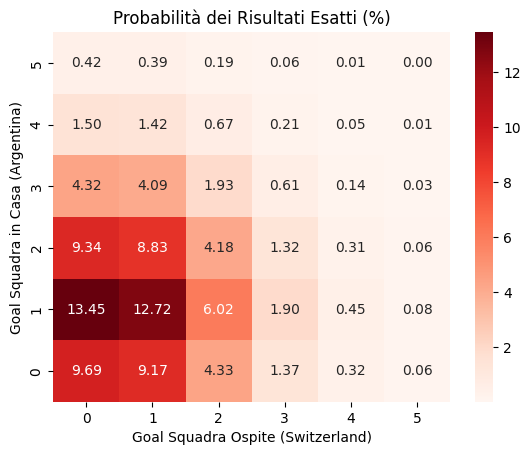

In [9]:
quarti = test[(test['goals'].isna()) & ((test['team'] == 'Argentina') | (test['team'] == 'Switzerland'))]
quarti

lambd_home = quarti['expected_goals'].iloc[0]
lambd_away = quarti['expected_goals'].iloc[1]

lambd_home
lambd_away

array_goal = np.arange(6)

probhome = poisson.pmf(array_goal, lambd_home)
probaway = poisson.pmf(array_goal, lambd_away)

M = np.outer(probhome, probaway)

matrix = pd.DataFrame(M*100)

sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Reds", cbar=True)
plt.gca().invert_yaxis()
plt.title("Probabilità dei Risultati Esatti (%)")
plt.ylabel("Goal Squadra in Casa (Argentina)")
plt.xlabel("Goal Squadra Ospite (Switzerland)")
plt.show()